# Attention on the sphere

This guide explains the two spherical attention layers in torch-harmonics:
global {class}`~torch_harmonics.AttentionS2` and local
{class}`~torch_harmonics.NeighborhoodAttentionS2`.  Both adapt standard
scaled dot-product attention to the sphere by incorporating the numerical
quadrature weights of the grid into the attention mechanism, following
[Bonev et al., NeurIPS 2025](https://arxiv.org/abs/2505.11157).

## 1. From planar to spherical attention

Standard scaled dot-product attention computes, for every query position
$x'$, a weighted sum of values over a set of key positions:

$$
\text{Attn}(Q, K, V)_{x'}
    = \sum_{x} \text{softmax}_{x}\!\left(
        \frac{Q(x') \cdot K(x)}{\sqrt{d_k}}
      \right)\, V(x)
$$

On a flat, uniformly-spaced grid every point carries equal weight, so the
softmax normalisation alone is sufficient.  On the **sphere**, however,
grid points near the poles are over-represented relative to their solid
angle: an equiangular grid has far more points per unit area near the poles
than at the equator.

To make attention geometrically faithful, we need to turn the sum into a
**quadrature approximation of a continuous integral** over the sphere.

## 2. Quadrature-weighted attention

The key insight is to fold the spherical quadrature weights $q_i$ into the
softmax.  Instead of normalising by the raw exponentials, we normalise by
a weighted sum:

$$
\text{Attn}(Q, K, V)_{x'}
    = \frac{
        \sum_{x} q(x)\,
        \exp\!\left(\frac{Q(x') \cdot K(x)}{\sqrt{d_k}}\right)\, V(x)
      }{
        \sum_{x} q(x)\,
        \exp\!\left(\frac{Q(x') \cdot K(x)}{\sqrt{d_k}}\right)
      }
$$

where $q(x) = 2\pi\, w_k / N_\lambda$ is the spherical quadrature weight
at input point $x = (\theta_k, \lambda_j)$.

### Implementation via log-weights

Because the exponential is inside both numerator and denominator, we can
equivalently add $\log q(x)$ to the pre-softmax attention scores:

$$
\alpha_{x',x} = \text{softmax}_{x}\!\left(
    \frac{Q(x') \cdot K(x)}{\sqrt{d_k}} + \log q(x)
\right)
$$

This is passed directly as the `attn_mask` argument to PyTorch's
`scaled_dot_product_attention`, making it a drop-in replacement for
standard attention with minimal code changes.

### Why this matters

Incorporating the quadrature weights makes the attention layer:

- **Resolution-agnostic**: the same learned weights can be evaluated on
  different grid resolutions (though the learned features remain resolution
  dependent).
- **Approximately $SO(3)$-equivariant**: the underlying integral is
  invariant under rotations (the Haar measure on $S^2$), so the
  discretised version inherits approximate equivariance.

## 3. Global attention ({class}`~torch_harmonics.AttentionS2`)

Global attention lets every output point attend to **all** input points.
The cost is $\mathcal{O}(N^2)$ in the number of grid points.
The forward pass follows the standard multi-head attention pattern:

1. **Linear projections**: project the input into queries $Q$, keys $K$,
   and values $V$ using pointwise (1×1) convolutions.
2. **Reshape** into `num_heads` independent attention heads.
3. **Scaled dot-product attention** with the log-quadrature-weight mask.
4. **Output projection**: another pointwise convolution.

The module supports self-attention (default) and cross-attention (pass
separate `key`/`value` tensors).

## 4. Neighborhood attention ({class}`~torch_harmonics.NeighborhoodAttentionS2`)

For high-resolution grids, global attention becomes prohibitively expensive.
Neighborhood attention restricts each output point to attend only to the
input points inside a geodesic disk of radius `theta_cutoff`:

$$
D(x') = \{x \in S^2 : d(x, x') \le \theta_\text{cutoff}\}
$$

where $d(\cdot, \cdot)$ is the great-circle distance.  This reduces the
cost from $\mathcal{O}(N^2)$ to $\mathcal{O}(kN)$, where $k$ is the
number of neighbors.

### Shared structure with DISCO convolutions

The sparse neighborhood structure is precomputed using the **same
discrete-continuous construction** as the DISCO convolutions
(see {doc}`/guide/disco_convolutions`).  Specifically, the support
(index information) of a zeroth-order DISCO kernel defines the indicator
function of the cutoff disk.  This means:

- **Sparsity**: only input points inside the angular cap contribute.
- **Longitude invariance (p-shift)**: the neighborhood structure is
  independent of the output longitude, just like the $\Psi$ tensor.

The relative weight of each input point depends on both its contribution
to the softmax and its quadrature weight.

### Online softmax

The forward pass uses a single-pass
[online softmax](https://arxiv.org/abs/1805.02867) algorithm: for each
output location, the neighbor list is iterated once while maintaining a
running maximum and accumulator.  This avoids materialising the full
attention matrix and is numerically stable.

## 5. Example: creating attention layers

Attention layers are data-dependent — unlike convolutions, their output
depends on the learned Q/K/V projections and how the input signal interacts
with them through the softmax.  With untrained (random) weights, the
attention scores are essentially uniform, so the output carries little
spatial structure.  Meaningful outputs require training on a downstream
task.

Here we show how to instantiate both modules and verify their input/output
shapes using the Mars MOLA elevation map.

In [1]:
import math

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

import torch_harmonics as th
from torch_harmonics.plotting import plot_sphere
from torch_harmonics.utils import load_mola_elevation

nlat, nlon = 64, 128
signal = load_mola_elevation(nlat, nlon).unsqueeze(0).unsqueeze(0)

In [2]:
in_channels = 1

# replicate to get multi-channel input
x = signal.expand(-1, in_channels, -1, -1).clone()

attn_global = th.AttentionS2(
    in_channels=in_channels,
    num_heads=1,
    in_shape=(nlat, nlon),
    out_shape=(nlat, nlon),
)

with torch.no_grad():
    y_global = attn_global(x)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {y_global.shape}")

Input shape:  torch.Size([1, 1, 64, 128])
Output shape: torch.Size([1, 1, 64, 128])


## 6. Example: neighborhood attention

Neighborhood attention uses the same API but confines each output point
to attend only within a geodesic disk of radius `theta_cutoff`.  Even with
untrained weights, the locality constraint means different output locations
see different subsets of the input, producing some spatial variation.

In [3]:
torch.manual_seed(333)

attn_local = th.NeighborhoodAttentionS2(
    in_channels=in_channels,
    num_heads=1,
    in_shape=(nlat, nlon),
    out_shape=(nlat, nlon),
    theta_cutoff=0.2,
)

with torch.no_grad():
    y_local = attn_local(x)

print(f"Input shape:  {x.shape}")
print(f"Output shape: {y_local.shape}")

Input shape:  torch.Size([1, 1, 64, 128])
Output shape: torch.Size([1, 1, 64, 128])


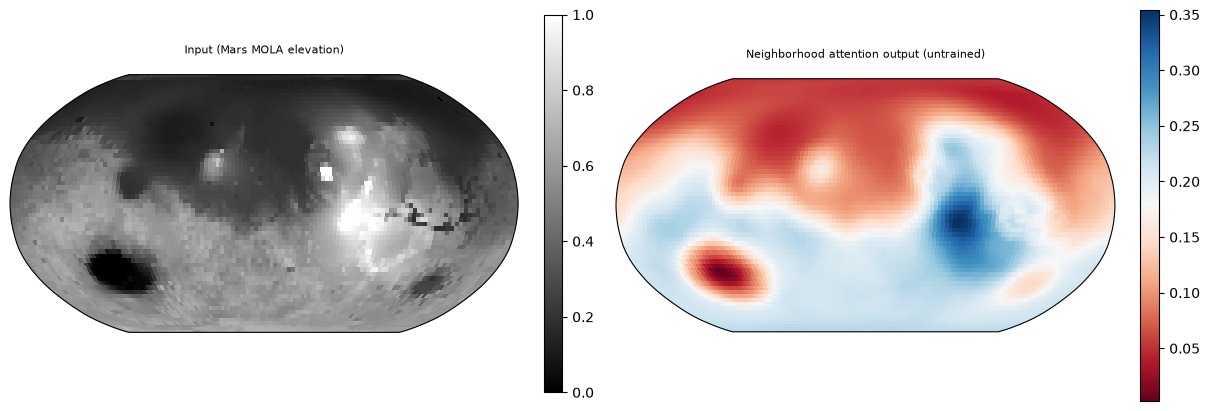

In [4]:
fig = plt.figure(figsize=(12, 4), layout="constrained")
subfigs = fig.subfigures(1, 2)

plot_sphere(x[0, 0], fig=subfigs[0], cmap="gray",
            title="Input (Mars MOLA elevation)", colorbar=True)

plot_sphere(y_local[0, 0].detach(), fig=subfigs[1], cmap="RdBu",
            title="Neighborhood attention output (untrained)", colorbar=True)

plt.show()

## 7. Neighborhood sparsity

Like the DISCO convolution's $\Psi$ tensor, the neighborhood attention's
sparse index structure scales linearly with the number of grid points.
Let's inspect how `theta_cutoff` affects the number of neighbors.

In [5]:
for tc in [0.05, 0.1, 0.2, 0.4]:

    torch.manual_seed(333)

    attn_tc = th.NeighborhoodAttentionS2(
        in_channels=1,
        num_heads=1,
        in_shape=(nlat, nlon),
        out_shape=(nlat, nlon),
        theta_cutoff=tc,
    )
    nnz = attn_tc.psi_col_idx.numel()
    avg_neighbors = nnz / (nlat * nlon)
    print(f"theta_cutoff={tc:.2f} rad ({math.degrees(tc):5.1f} deg): "
          f"{nnz:>8,} neighbor pairs, "
          f"avg {avg_neighbors:.1f} neighbors/output")

theta_cutoff=0.05 rad (  2.9 deg):    1,272 neighbor pairs, avg 0.2 neighbors/output
theta_cutoff=0.10 rad (  5.7 deg):    3,290 neighbor pairs, avg 0.4 neighbors/output
theta_cutoff=0.20 rad ( 11.5 deg):    9,902 neighbor pairs, avg 1.2 neighbors/output
theta_cutoff=0.40 rad ( 22.9 deg):   31,154 neighbor pairs, avg 3.8 neighbors/output


## 8. Cross-attention and downsampling

Both attention modules support **cross-attention**: pass separate `key`
and `value` tensors sampled on the input grid, while the `query` lives on
the output grid.  When the input and output grids differ in resolution,
this naturally performs **downsampling** (or **upsampling** for
neighborhood attention).

In [6]:
nlat_out, nlon_out = 32, 64

torch.manual_seed(333)

attn_down = th.NeighborhoodAttentionS2(
    in_channels=in_channels,
    num_heads=1,
    in_shape=(nlat, nlon),
    out_shape=(nlat_out, nlon_out),
    theta_cutoff=0.2,
)

# query on the coarser grid, key/value on the finer grid
query = F.interpolate(signal, size=(nlat_out, nlon_out), mode="bilinear",
                      align_corners=False).expand(-1, in_channels, -1, -1).clone()
key_val = x

with torch.no_grad():
    y_down = attn_down(query, key=key_val, value=key_val)

print(f"Query shape:  {query.shape}")
print(f"Key shape:    {key_val.shape}")
print(f"Output shape: {y_down.shape}")

Query shape:  torch.Size([1, 1, 32, 64])
Key shape:    torch.Size([1, 1, 64, 128])
Output shape: torch.Size([1, 1, 32, 64])


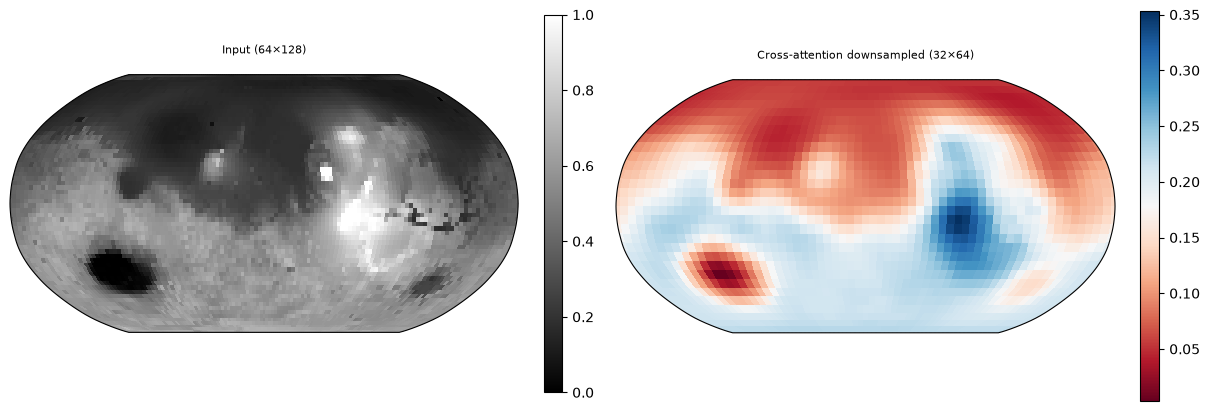

In [7]:
fig = plt.figure(figsize=(12, 4), layout="constrained")
subfigs = fig.subfigures(1, 2)

plot_sphere(x[0, 0], fig=subfigs[0], cmap="gray",
            title=f"Input ({nlat}×{nlon})", colorbar=True)

plot_sphere(y_down[0, 0].detach(), fig=subfigs[1], cmap="RdBu",
            title=f"Cross-attention downsampled ({nlat_out}×{nlon_out})", colorbar=True)

plt.show()

## 9. Choosing `theta_cutoff`

`theta_cutoff` plays the same role as in DISCO convolutions — it controls
the receptive field of each output point:

- **Smaller** `theta_cutoff` means fewer neighbors (faster, less memory)
  but a more local receptive field.
- **Larger** `theta_cutoff` approaches global attention in the limit
  ($\theta_\text{cutoff} = \pi$ recovers full attention over the sphere).
- If not specified, it defaults to one latitudinal grid spacing:
  $\pi / (N_\text{lat} - 1)$.

In practice, stacking multiple neighborhood attention layers (potentially
with different resolutions in a U-Net) gives a large effective receptive
field while keeping each individual layer cheap.

## 10. Global vs. neighborhood attention

| | Global (`AttentionS2`) | Neighborhood (`NeighborhoodAttentionS2`) |
|---|---|---|
| **Receptive field** | Full sphere | Geodesic disk of radius `theta_cutoff` |
| **Cost** | $\mathcal{O}(N^2)$ | $\mathcal{O}(kN)$ |
| **Quadrature weights** | Log-weights as `attn_mask` | Weights folded into sparse softmax |
| **Implementation** | PyTorch `scaled_dot_product_attention` | Custom online-softmax kernel |
| **Cross-attention** | Yes | Yes |
| **Up/downsampling** | Downsample only | Both (via p-shift direction) |
| **Custom CUDA kernel** | No (uses PyTorch SDPA) | Yes (optional, with C++ fallback) |

## Summary

- Spherical attention adapts standard scaled dot-product attention to the
  sphere by incorporating **quadrature weights** into the softmax
  normalisation, making it a discretised integral over the sphere.
- **Global attention** ({class}`~torch_harmonics.AttentionS2`) uses all
  grid points as keys and achieves this via log-quadrature-weight masks.
- **Neighborhood attention** ({class}`~torch_harmonics.NeighborhoodAttentionS2`)
  restricts attention to a geodesic disk of radius `theta_cutoff`,
  reducing cost from $\mathcal{O}(N^2)$ to $\mathcal{O}(kN)$.
- The neighborhood structure reuses the **DISCO sparsity pattern**
  (compact support + p-shift), making it efficient and longitude-invariant.
- Both layers are approximately **$SO(3)$-equivariant** and
  **resolution-agnostic**.

```{tip}
When running on **CPU**, the neighborhood attention kernels are
parallelised with OpenMP.  Setting `OMP_NUM_THREADS` to the number of
physical cores can significantly improve performance.  The optimal thread
binding depends on your hardware:

- `OMP_PROC_BIND=close` packs threads onto adjacent cores, which is
  usually best on single-socket machines where threads benefit from
  shared cache.
- `OMP_PROC_BIND=spread` distributes threads across sockets or chiplets,
  which can be better on multi-socket or AMD EPYC systems where aggregate
  memory bandwidth is the bottleneck.

For Intel OpenMP, the equivalent settings are `KMP_AFFINITY=compact` and
`KMP_AFFINITY=scatter`.

    export OMP_NUM_THREADS=8
    export OMP_PROC_BIND=close   # or spread on multi-socket systems
```

For the full parameter documentation, see
{class}`~torch_harmonics.AttentionS2` and
{class}`~torch_harmonics.NeighborhoodAttentionS2`.